# 04 · 제안 모델 EMFN v3의 구조·학습·결과

주 구현: `src/models/emfn.py`. 손실·학습: `hurdle_beta.py`, `emfn_trainer.py`. 아래 구조와 파라미터 표는 실제 생성자를 호출합니다. 이 모델은 유계 출력과 영발전 질량을 갖는 통계적 확률 모델이며 제조사 cut-in/cut-out 제어 법칙이나 인과 효과를 직접 식별하지 않습니다.

In [1]:
from pathlib import Path
import os, sys
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "configs/base_config.yaml").exists())
os.chdir(ROOT)
sys.path.insert(0, str(ROOT))
runtime = ROOT / ".experiment_archive/python_runtime"
if runtime.exists(): sys.path.insert(0, str(runtime))
from IPython.display import display
from src.workflows import research as wf
%matplotlib inline

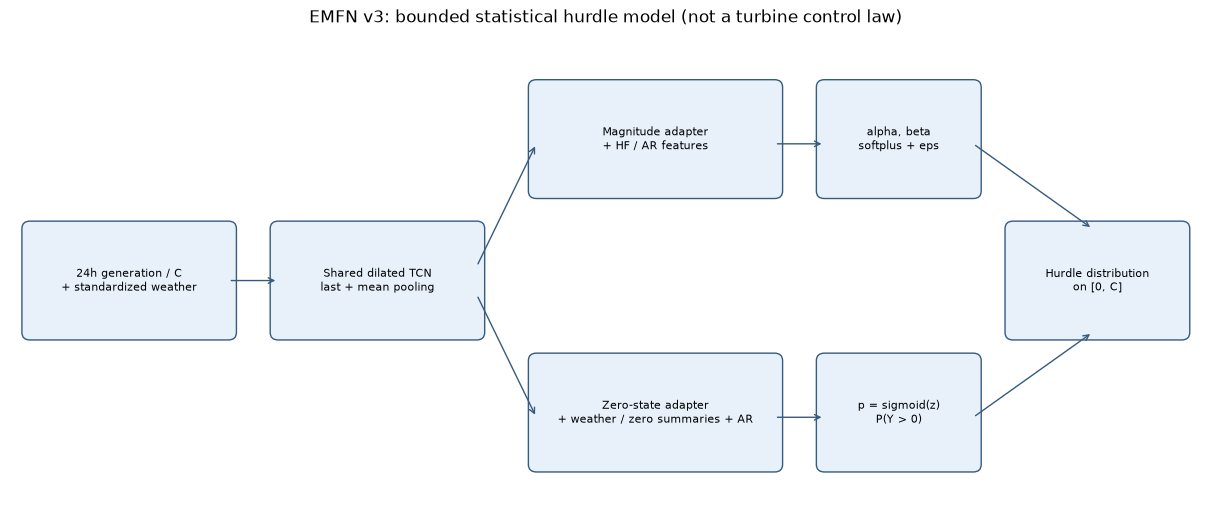

In [2]:
wf.plot_architecture();

In [3]:
wf.architecture_table()

,module,type,parameters
0,tcn,Sequential,89408
1,mag_adapter,Sequential,8256
2,ar_shortcut,Linear,25
3,head_alpha,Sequential,4545
4,head_beta,Sequential,4545
5,zero_adapter,Sequential,8256
6,selective_gate,Sequential,816
7,head_zero,Sequential,5313


## 1. 허들 출력과 학습 목적

입력 발전량은 항상 C=21로 나눕니다. 공유 TCN → magnitude/zero adapter 두 분기. magnitude는 HF·AR, zero는 기상 및 과거 영발전 요약 특징을 추가합니다. GroupNorm이 윈도우 안 시간축을 함께 사용하므로 중간 토큰의 엄격한 prefix causality를 주장하지 않습니다. 발행 시점 이후 관측은 입력에 넣지 않습니다.

- 코드의 `z_zero` 이름과 달리 $p=\sigma(z_{zero})=P(Y>0\mid X)$.
- $P(Y=0)=1-p$, $Y/C\mid Y>0\sim Beta(\alpha,\beta)$.
- $E[Y\mid X]=C p\alpha/(\alpha+\beta)$; MAE에는 혼합분포 중앙값을 사용합니다.
- 양수에서 Beta NLL + Bernoulli NLL + 2×정규화 평균의 Huber loss. eps는 수치 안정화에 쓰이며 영발전 라벨은 정확한 0입니다.
- 0에는 점질량이 있고 C에는 별도 점질량이 없습니다. 이는 예측 불확실성이며 베이지안 모수 사후분포가 아닙니다.

## 2. 단일 EMFN 재학습 (선택)

False가 기본입니다. True로 바꾸면 고정된 설정의 +1h/seed42를 직접 학습하고 별도 로컬 실험 폴더에 저장합니다. 본문 점수는 03에서 생성·검증한 전체 실행만 사용하며 여기의 추가 실행으로 좋은 결과를 골라 바꾸지 않습니다.

In [4]:
RUN_EMFN_EXAMPLE = False
if RUN_EMFN_EXAMPLE:
    display(wf.train_emfn_example(horizon=1, seed=42))

## 3. 검증 CRPS 체크포인트 선택

예시는 사전에 정한 +6h/seed42입니다. epoch별 검증 CRPS와 선택 epoch는 해당 checkpoint의 `.pt.history.json`에서 읽습니다.

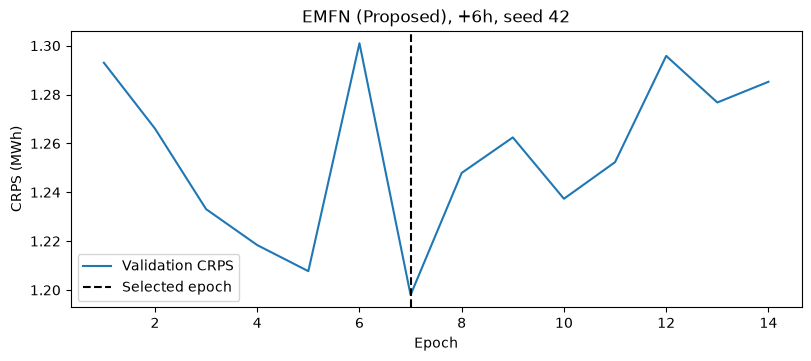

In [5]:
wf.plot_training(model="EMFN (Proposed)", horizon=6, seed=42);

In [6]:
wf.display_scores(models=["EMFN (Proposed)"], horizons=None)

,model,horizon_hours,n_fits,crps,zero_brier,rmse,mae,zero_auprc
0,EMFN (Proposed),1,3,0.5802 ± 0.0058,0.0693 ± 0.0017,1.2879 ± 0.0155,0.8003 ± 0.0099,0.7516 ± 0.0028
1,EMFN (Proposed),3,3,1.0563 ± 0.0363,0.0963 ± 0.0027,2.3238 ± 0.0652,1.4748 ± 0.0422,0.5601 ± 0.0114
2,EMFN (Proposed),6,3,1.4529 ± 0.0329,0.1144 ± 0.0006,3.1678 ± 0.0647,2.0239 ± 0.0378,0.4343 ± 0.0043
3,EMFN (Proposed),9,3,1.6732 ± 0.0404,0.1279 ± 0.0025,3.5666 ± 0.0758,2.3318 ± 0.0466,0.3469 ± 0.0233
4,EMFN (Proposed),12,3,1.8206 ± 0.0048,0.1248 ± 0.0009,3.8347 ± 0.0006,2.5392 ± 0.0213,0.3391 ± 0.0028
5,EMFN (Proposed),24,3,2.2019 ± 0.0276,0.1353 ± 0.0008,4.4437 ± 0.0490,3.1100 ± 0.0565,0.2363 ± 0.0040


## 4. 예측 평균·중앙값·구간

아래는 +6h/seed42의 개발 평가 첫 7개 가용 일자입니다. 잘 맞는 구간을 사후 선정한 그림이 아닙니다. 구간이 좁은 것만으로 보정이 좋다고 해석하지 않고 포함률과 함께 검토합니다.

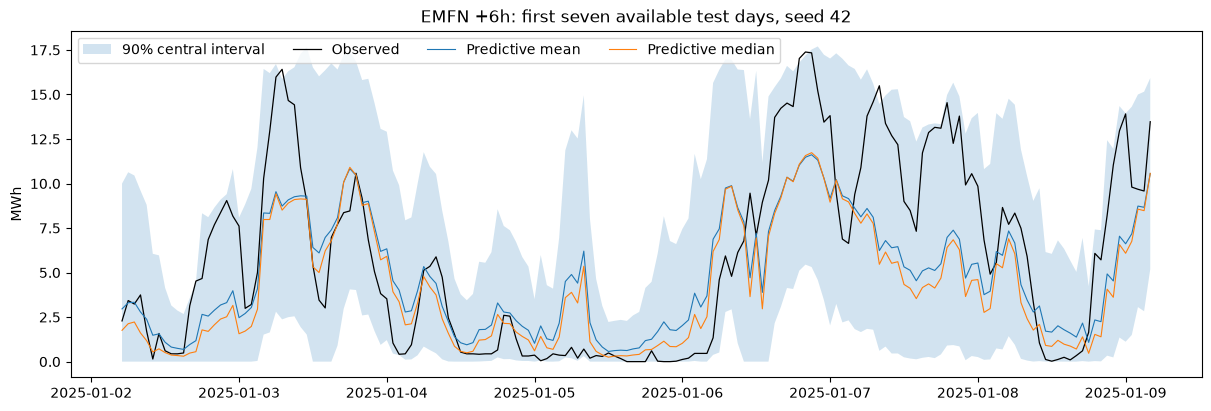

In [7]:
wf.plot_forecast(horizon=6, seed=42);

## 5. 구조 기여 검증의 현재 경계

`src/models/emfn_ablation.py`의 shared_adapter / 기상 상태 특징 제거 / HF·AR 제거 / 공통 표현 구조의 linear·sigmoid·hurdle 대조군은 구현·합성 검증 상태입니다. 실제 126개 구조 학습은 아직 수행하지 않았습니다. 과거 `regression_mode`는 Route B와 gate도 제거하므로 순수 출력 헤드 비교가 아닙니다. 이 노트북은 준비 상태를 완료 결과처럼 보여주지 않습니다.

**다음:** [05 · 전체 비교와 논문용 정리](05_comparison_and_research_limits.ipynb).